In [1]:
# param
variante = "rgb"                  #rgb nb contours
normalisation = "normalisee"  # normalisee non_normalisee
epochs = 100
lr = 0.01

In [2]:
# compile linear_model.c et lance le binaire
import subprocess
from pathlib import Path

# racine
racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

chemin_c = racine / "models" / "lineaire" / "linear_model.c"
chemin_exec = racine / "models" / "lineaire" / "linear_model"

subprocess.check_call(["gcc", str(chemin_c), "-o", str(chemin_exec), "-lm"], cwd=str(racine))

base = racine / "datasets" / "transformed" / variante / normalisation
cmd = [
    str(chemin_exec),
    str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
    str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
    str(epochs), str(lr),
]

sortie = subprocess.check_output(cmd, text=True, cwd=str(racine))
# on affiche pas les lignes epoch (courbe plus bas)
for ligne in sortie.splitlines():
    if not ligne.startswith("epoch "):
        print(ligne)

Chargé train: n=1200, d=49152
Chargé test : n=301, d=49152
Entraînement perceptron multi-classes (K=3), epochs=100, lr=0.0100
pocket epoch 93 train 0.846
acc train 0.846
acc test 0.528
confusion
56 9 33
39 32 35
21 5 71


In [3]:
# recup acc& confusion depuis  texte du C
epochs_liste = []
acc_train = []
acc_test = []
acc_train_finale = None
acc_test_pocket = None
confusion = None

lignes = sortie.strip().splitlines()
for ligne in lignes:
    if ligne.startswith("epoch "):
        m = ligne.split()   # epoch 3 train 0.612 test 0.470
        epochs_liste.append(int(m[1]))
        acc_train.append(float(m[3]))
        acc_test.append(float(m[5]))
    # avec le pocket le score final c'est plus la derniere epoch, on lit les lignes acc
    if ligne.startswith("acc train"):
        acc_train_finale = float(ligne.split()[2])
    if ligne.startswith("acc test"):
        acc_test_pocket = float(ligne.split()[2])

for i, ligne in enumerate(lignes):
    if ligne.strip() == "confusion":
        confusion = [[int(x) for x in lignes[i + 1 + j].split()] for j in range(3)]
        break

print("acc train finale (pocket):", acc_train_finale)
print("acc test finale (pocket) :", acc_test_pocket)
print("confusion:", confusion)

acc train finale (pocket): 0.846
acc test finale (pocket) : 0.528
confusion: [[56, 9, 33], [39, 32, 35], [21, 5, 71]]


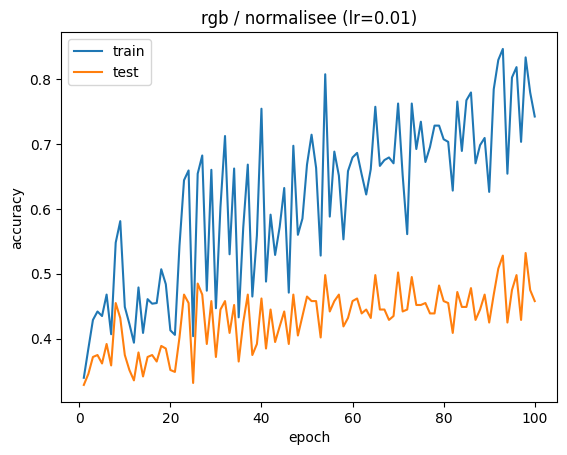

In [4]:
# train vs test (
import matplotlib.pyplot as plt

plt.plot(epochs_liste, acc_train, label="train")
plt.plot(epochs_liste, acc_test, label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"{variante} / {normalisation} (lr={lr})")
plt.legend()
plt.show()

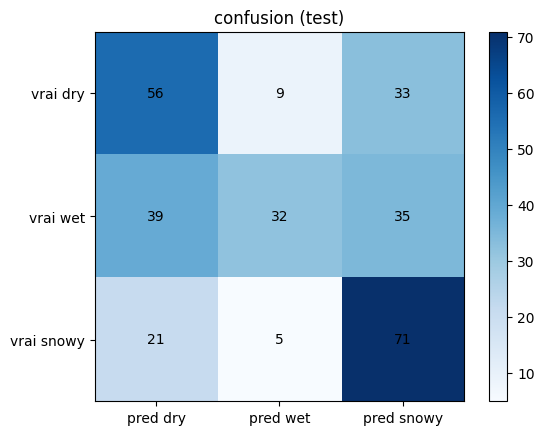

In [5]:
# matrice de confusio
plt.imshow(confusion, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], ["pred dry", "pred wet", "pred snowy"])
plt.yticks([0, 1, 2], ["vrai dry", "vrai wet", "vrai snowy"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion[i][j], ha="center", va="center")
plt.title("confusion (test)")
plt.show()

In [6]:
# precision / rappel / f1 par classe, calcules a la main depuis la confusion
noms_classes = ["dry", "wet", "snowy"]
for k in range(3):
    vp = confusion[k][k]
    fp = sum(confusion[i][k] for i in range(3) if i != k)
    fn = sum(confusion[k][j] for j in range(3) if j != k)
    precision = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    rappel = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0.0
    print(f"{noms_classes[k]:6s} precision={precision:.3f} rappel={rappel:.3f} f1={f1:.3f}")


dry    precision=0.483 rappel=0.571 f1=0.523
wet    precision=0.696 rappel=0.302 f1=0.421
snowy  precision=0.511 rappel=0.732 f1=0.602


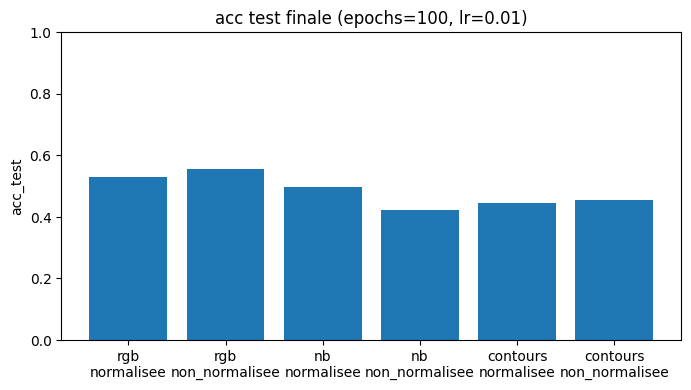

In [6]:
# meme modele 6 variantes
def acc_test_finale(variante, normalisation):
    base = racine / "datasets" / "transformed" / variante / normalisation
    cmd = [
        str(chemin_exec),
        str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
        str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
        str(epochs), str(lr),
    ]
    sortie = subprocess.check_output(cmd, text=True, cwd=str(racine))
    # score pocket (ligne acc test), pas derniere epoch
    for ligne in sortie.strip().splitlines():
        if ligne.startswith("acc test"):
            return float(ligne.split()[2])
    return None

labels = []
valeurs = []
for v in ["rgb", "nb", "contours"]:
    for norm in ["normalisee", "non_normalisee"]:
        labels.append(f"{v}\n{norm}")
        valeurs.append(acc_test_finale(v, norm))

plt.figure(figsize=(8, 4))
plt.bar(labels, valeurs)
plt.ylabel("acc_test")
plt.title(f"acc test finale (epochs={epochs}, lr={lr})")
plt.ylim(0, 1)
plt.show()